**420-C74-SF - Techniques d'apprentissage automatique - Automne 2026 - Spécialiste en solutions d'intelligence artificielle**<br/>
© 2026 MKL.AI - Tous droits réservés
<br/>
![Atelier - Fonction de coût](static/03-A-banner.png)
<br/>
**Objectif:** cette séance de travaux pratique a pour objectif la compréhension des différents aspects de la **fonction de coût** en régression linéaire simple

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

### 0 - Chargement des bibliothèques

In [2]:
# Manipulation de données
import numpy as np
import pandas as pd
from collections import defaultdict

# Visualisation de données
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
import seaborn as sns

# Outils divers
from tqdm.notebook import tqdm_notebook
from tqdm import tqdm

In [3]:
# Configuration de la visualisation
sns.set_theme(style="darkgrid", rc={'figure.figsize':(11.7,8.27)})

### 1 - Simulation d'un jeu de données

In [4]:
m = 200

In [5]:
# Ce code Python génère un jeu de données fictif (synthétique) de 200 points pour simuler un problème de régression linéaire avec du bruit aléatoire.

# 1. Fixation du hasard
# Rôle : Initialise le générateur de nombres aléatoires.
# Effet : Garantit que les nombres "aléatoires" générés ensuite seront exactement les mêmes
# à chaque exécution du code. C'est essentiel pour la reproductibilité en science des données.
np.random.seed(2020) # Pour la reproductibilité des résultats

# 2.Définition des paramètres théoriques (vraies valeurs)
# Rôle : Définit la "vérité terrain" (ground truth), c'est-à-dire l'équation mathématique parfaite cachée derrière les données.
# Modèle idéal : La droite théorique est donc \(y = -0.5 + 0.75x\).
theta_0_th = -0.5 # Ordonnée à l'origine, c'est visuellement le point exact où la droite de régression coupe l'axe vertical (l'axe des y).
theta_1_th = 0.75 # La pente (slope ou coeffichient de régression, c'est le taux de changement de y pour chaque augmentation d'une unité de x).

# 3. Génération de la variable explicative (x) --> variable indépendante ou feature
# Rôle : Crée un tableau de 200 valeurs (m=200) pour la variable x.
# Effet : Les valeurs sont tirées de manière uniforme (probabilité égale) entre 1 et 10.
x = np.random.uniform(1,10,m)

# 4. Génération de la valeur cible (y) --> variable dépendante, target avec du bruit
# Rôle : Calcule les 200 valeurs correspondantes de \(y\), mais ajoute une perturbation.
# Le "Bruit" (np.random.randn(m)) : Ajoute une distribution normale (gaussienne) centrée sur 0 avec un écart-type de 1 pour chaque point.
# Effet concret : Sans ce bruit, tous les points de votre graphique seraient parfaitement alignés sur la droite.
# Grâce à ce bruit, les points sont légèrement dispersés autour de la droite, ce qui imite de vraies données du monde réel.
y = theta_0_th + (theta_1_th * x) + np.random.randn(m)


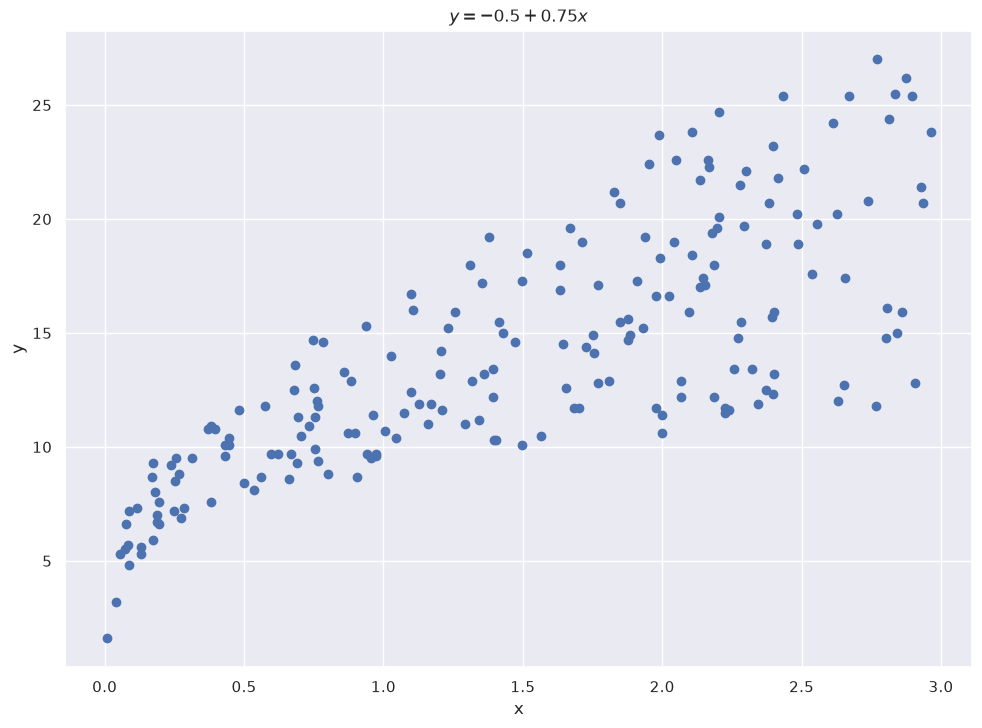

In [27]:
import sympy as sp

# Define symbolic variables
sym_x, sym_y, sym_theta_0, sym_theta_1 = sp.symbols('x y theta_0 theta_1')

fig, ax = plt.subplots()
ax.scatter(x,y)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(rf"$y = {theta_0_th} + {theta_1_th}x$")

plt.show()

### 2 - Définition d'un modèle de régression linéaire simple

**Exercice 1**: compléter la fonction ci-dessous représentant le modèle de régression linéaire simple (hypothèse)

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
Pour rappel, le modèle de régression linéaire simple est
$h_{\theta}(x)=\theta_{0} + \theta_{1}x$
</p>

Sachant que: $h_\theta(x) = \theta_0 + \theta_1 x$

In [7]:
def hypothesis(x, theta_0, theta_1):
    
    # Compléter le code ci-dessous ~ 1 ligne
    h = theta_0 + (theta_1 * x)
    return h

In [8]:
import sympy as sp
from IPython.display import Math

# Define symbolic variables
sym_x, sym_theta_0, sym_theta_1 = sp.symbols('x theta_0 theta_1')

def hypothesis_latex():
    # Create an expression representing the hypothesis function
    expr = sym_theta_0 + (sym_theta_1 * sym_x)
    
    # Convert the expression into a LaTeX string
    latex_string = sp.latex(expr, mode='inline')
    
    return Math(latex_string)

# Example usage of the method
latex_output = hypothesis_latex()
display(latex_output)

<IPython.core.display.Math object>

### 3 - Règlage des paramètres de manière manuelle

**Exercice 2**: Faites varier les paramètres $\theta_0$ et $\theta_1$ de manière à obtenir un bon "fit" sur les données simulées

Sachant que $\theta_0$ représente l'ordonnée à l'origine (valeur de $y$ lorsque $x$ est égal à zéro), c'est-à-dire le point exact où la droite de régression intersecte l'axe des $y$

Sachant que $\theta_1$ représente la pente (coefficient de régression), c'est-à-dire le taux de changement de $\$ pour chaque changement d'une unité de $x$

In [9]:
# On calcule les résidus
def rss(x, y, theta_0, theta_1):
    # Compléter le code ci-dessous ~ 1 ligne
    # s = np.sum((y - (theta_0 + (theta_1 * x)))**2)
    s = np.sum((y - (hypothesis(x, theta_0, theta_1)))**2)
    return s

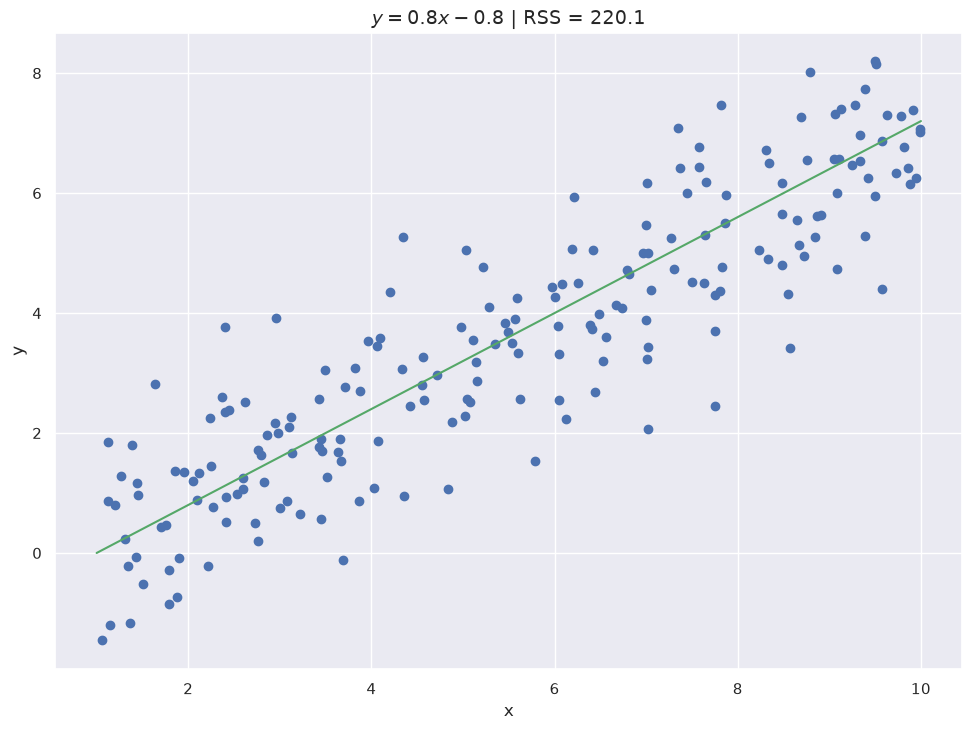

In [10]:
import sympy as sp

# 1. On définit la variable symbolique x
x_sym = sp.Symbol('x')

# Faire varier les deux valeurs ci-dessous ~ 2 lignes
theta_0 = -0.8
theta_1 = 0.8

# 2. On crée l'équation symbolique avec vos vraies valeurs
# SymPy va combiner 7 + 0.03 * x_sym en une expression mathématique
equation_sym = theta_0 + theta_1 * x_sym

# 3. On génère le code LaTeX propre (ex: "0.03 x + 7")
latex_formula = sp.latex(equation_sym)

# 4. On crée les données pour X et Y
reg_x = np.linspace(1,10,10)
reg_y = hypothesis(np.linspace(1,10,10), theta_0, theta_1)

fig, ax = plt.subplots()
ax.scatter(x,y)
ax.plot(reg_x, reg_y, color="g")
ax.set_xlabel("x")
ax.set_ylabel("y")

# 5. On affiche la formule LaTeX ET le RSS dans le titre
# Le "r" devant les guillemets est crucial pour que Matplotlib lise le LaTeX correctement
ax.set_title(r"$y = " + latex_formula + f"$ | RSS = {rss(x, y, theta_0, theta_1):.1f}", fontsize=14)

plt.show()

### 4 - Définition de la fonction de coût

**Exercice 3**: Compléter la fonction de coût ci-dessous

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>

<p>
Pour rappel, la fonction de coût en régression linéaire simple s'exprime sous la forme

$J(\theta_{0},\theta_{1})= \frac{1}{2m}\sum\limits_{i=1}^{m}(h_{\theta}(x^{(i)})-y^{(i)})^{2}$

coût = somme de 1 à m de 1/2m * (hypothèse h0 - écart) ** 2 (au carré) 
</p>

In [11]:
def cost_function(x,y, theta_0, theta_1):
    assert len(x) == len(y)
    # Compléter le code ci dessous ~ 1-4 lignes
    # On sait qu'ici m = 200 pour x et pour y
    m = len(x)

    # Calculer les prédictions h(x) = theta_0 + theta_1 * x
    predictions = theta_0 + (theta_1 * x)

    # On calcule le coût 
    cost = (1/(2*m)) * np.sum((predictions - y)**2)
    return cost

Pour l'illustration suivante, nous fixerons $\theta_0$ à 0 et ferons varier $\theta_1$ sur un interval donné

Le modèle (ou l'hypothèse) sera donc $h_{\theta}(x) = \theta_{1}x$

In [12]:
thetas = np.linspace(-1,2,20)
J = []
theta_0 = 0
for theta_1 in thetas:
    J.append(cost_function(x, y, theta_0, theta_1))

**Exercice 4**: selon la courbe ci-dessus, quelle est approximativement la valeur de $\theta_1$ qui minimise la fonction de coût ?

Text(0, 0.5, 'Coût')

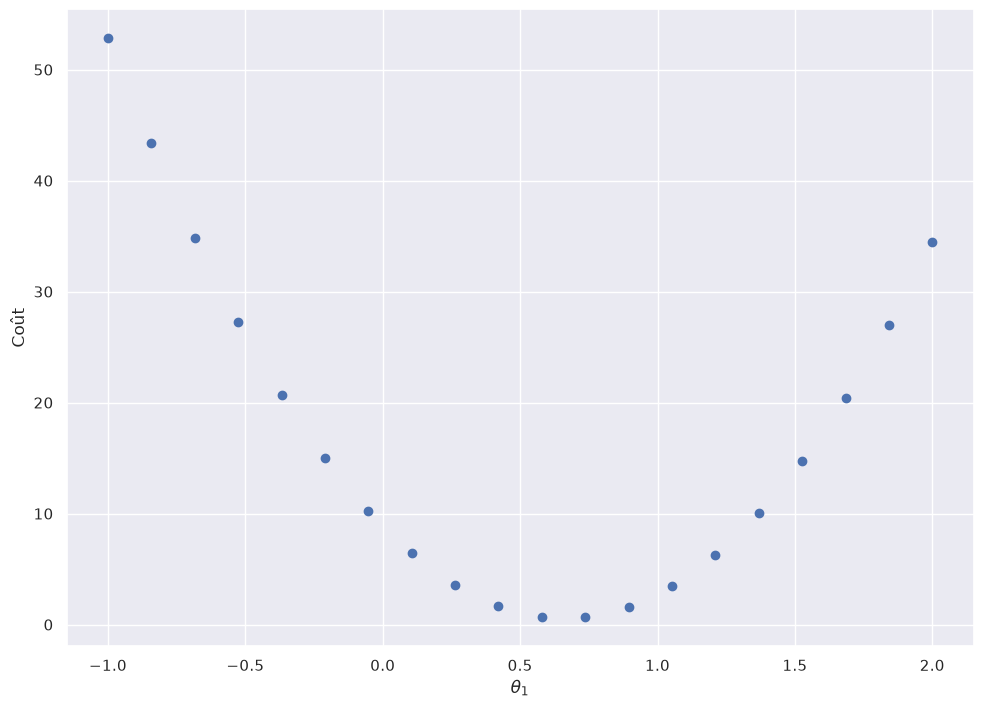

In [13]:
fig, ax = plt.subplots()
ax.scatter(thetas, J)
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel("Coût")

### 5 - Modèle complet

$h_{\theta}(x) = \theta_{0} + \theta_{1}x$

In [14]:
theta_0s = np.linspace(-4,2,50)
theta_1s = np.linspace(-1,2,50)
mesh = np.zeros((50,50))
for i, theta0 in enumerate(theta_0s):
    for j, theta1 in enumerate(theta_1s):
        mesh[i,j] = cost_function(x, y, theta0, theta1)

**Exercice 5**: selon la courbe ci-dessus, quelle sont approximativement les valeurs de $\theta_{0}$ et $\theta_{1}$ qui minimisent la fonction de coût ?

Text(0, 0.5, '$\\theta_1$')

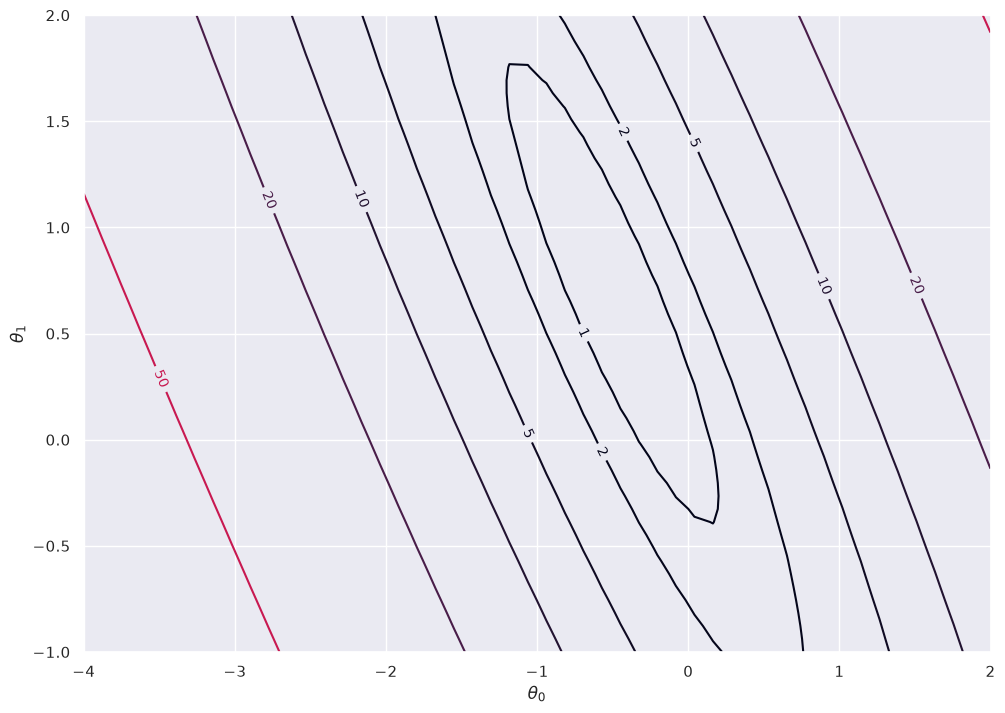

In [15]:
fig, ax = plt.subplots()
XX, YY = np.meshgrid(theta_0s,theta_1s)
CS = ax.contour(XX, YY, mesh, levels = [1,2,5,10,20,50,100])
ax.clabel(CS, inline=1, fontsize=10)
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')

Text(0.5, 0, 'J')

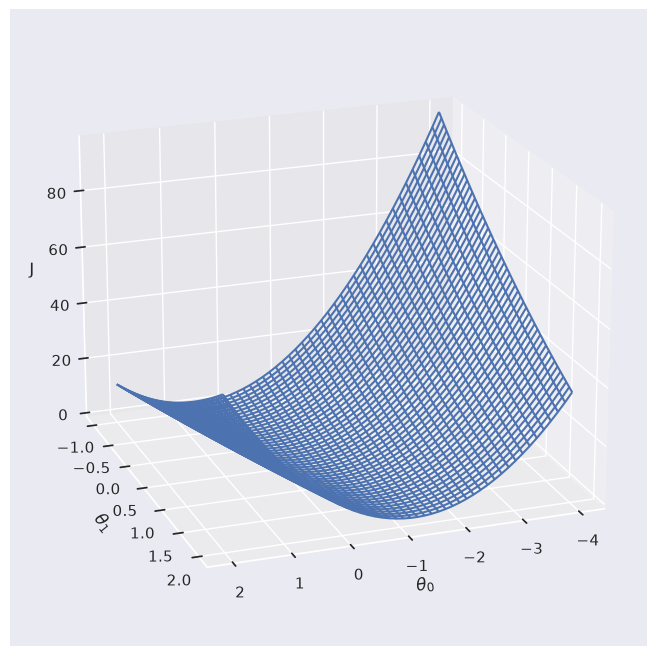

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(20, 70)
ax.plot_wireframe(XX, YY, mesh, rstride=1, cstride=1)
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_zlabel('J')

### 6 - Jeu de données advertising 

In [17]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

**Exercice 6**: à l'aide de la bibiothèques *pandas*, lire le fichier `advertising-univariate.csv`

In [18]:
# Compléter le code ci-dessous ~ 1 ligne
df = pd.read_csv("/workspaces/420-c74-sf-10017-automne-2026/data/advertising-univariate.csv")

#### 6-1 - Préparation de la structure de données

In [19]:
x = df['TV'].values
y = df['sales'].values


x = x/100 # Cette mise à l'échelle permet un meilleur affichage des résultats

#### 6-2 - Affichage des données

Text(0, 0.5, "Ventes (en millier d'unités)")

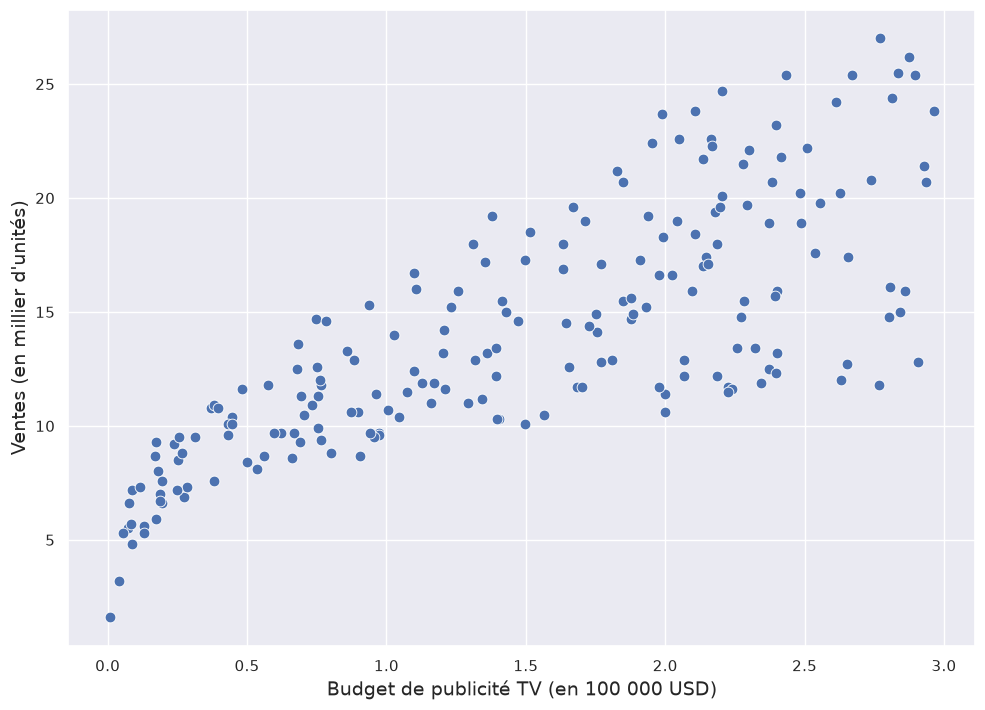

In [20]:
ax = sns.scatterplot(x=x, y=y, s=60)
ax.set_xlabel("Budget de publicité TV (en 100 000 USD)", fontsize=14)
ax.set_ylabel("Ventes (en millier d'unités)", fontsize=14)

**Exercice 7**: Faites varier les paramètres $\theta_{0}$ et $\theta_{1}$ de manière à obtenir un bon "fit" sur le jeu de données

Text(0, 25, 'J=5.256359952868247')

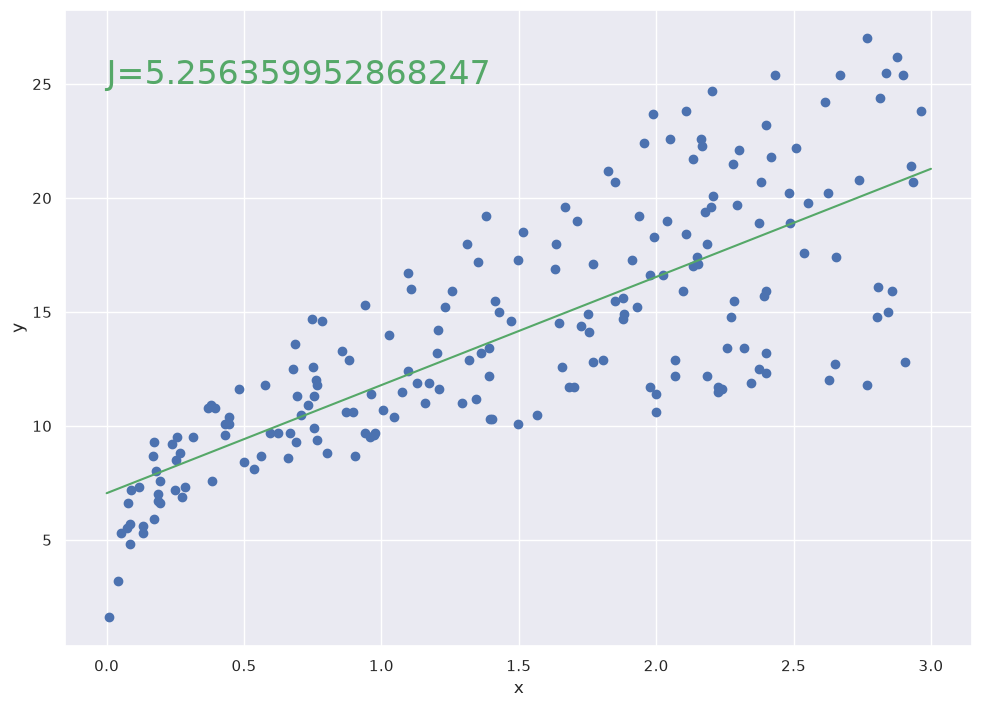

In [21]:
theta_0 = 7.048
theta_1 = 4.7443
reg_x = np.linspace(0,3,10)
reg_y = hypothesis(np.linspace(0,3,10), theta_0, theta_1)
fig, ax = plt.subplots()
ax.scatter(x,y)
ax.plot(reg_x, reg_y, color="g")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Calcul de la perte
J = cost_function(x,y, theta_0, theta_1)

ax.text(0,25,f'J={J}', color='g', fontsize=24)

#### 6-3 Modèle simplifié

**Exercice 8**: En utlisant le modèle simplifié ($\theta_0$ = 0), quelle est approximativement la valeur de $\theta_1$ qui minimise la fonction de coût ? Pourquoi la valeur semble différente de celle trouvée précédemment ?

Note: le modèle (ou l'hypothèse) sera donc $h_{\theta}(x) = \theta_{1}x$

In [22]:
thetas = np.linspace(7,12,20)
J = []
theta_0 = 0
for theta_1 in thetas:
    J.append(cost_function(x, y, theta_0, theta_1))

Text(0, 0.5, '$J(\\theta_1)$')

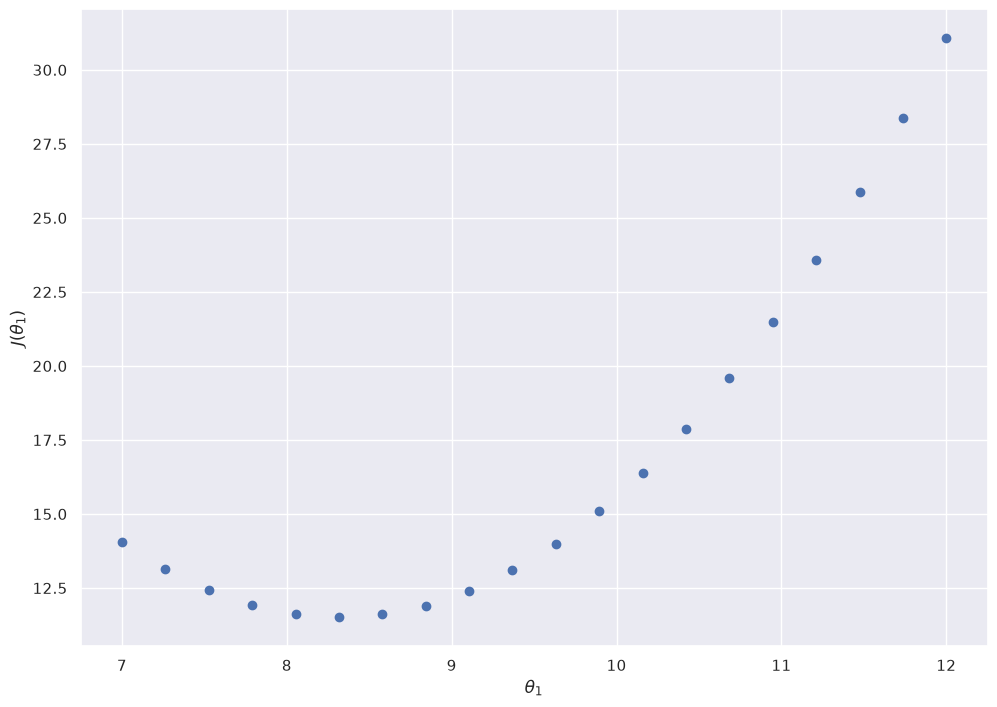

In [23]:
fig, ax = plt.subplots()
ax.scatter(thetas, J)
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$J(\theta_1)$")

#### 6-3 Modèle complet

$h_{\theta}(x) = \theta_{0} + \theta_{1}x$

**Exercice 9**: selon la courbe ci-dessus, quelle sont approximativement les valeurs de $\theta_{0}$ et $\theta_{1}$ qui minimisent la fonction de coût ?

In [24]:
theta_0s = np.linspace(4,9,50)
theta_1s = np.linspace(4.5,5.5,50)
mesh = np.zeros((50,50))
for i, theta_0 in enumerate(theta_0s):
    for j, theta_1 in enumerate(theta_1s):
        mesh[j,i] = cost_function(x, y, theta_0, theta_1)

Text(0, 0.5, '$\\theta_1$')

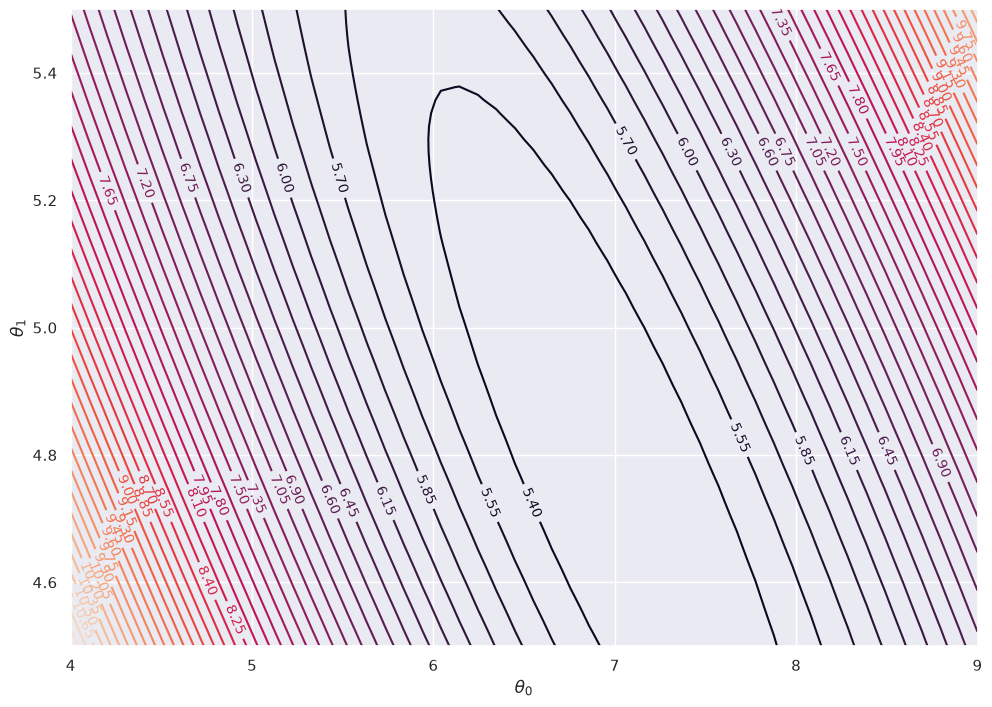

In [25]:
fig, ax = plt.subplots()
XX, YY = np.meshgrid(theta_0s,theta_1s)
CS = ax.contour(XX, YY, mesh, levels=40)
ax.clabel(CS, inline=1, fontsize=10)
ax.set_xlabel(r"$\theta_0$")
ax.set_ylabel(r"$\theta_1$")

### Fin de l'atelier